# Quark vs Gluon Jet Classification using Machine Learning

### Comparison of Lab Frame and Rest Frame Features

## Summary

In this project, we perform a detailed analysis of the Pythia8 quark and gluon jet dataset using a combined dataset of 300,000 jets (150,000 quark and 150,000 gluon). We begin with robust data preprocessing, carefully handling zero-padded constituents and retaining only physically meaningful particles using a transverse momentum mask.

Our exploratory analysis reveals clear and physically consistent differences between jet types. Gluon jets contain significantly more constituents (~ 7.98 million) compared to quark jets (~5.01 million), reflecting their larger color factor and stronger radiation pattern. The multiplicity distribution confirms that gluon jets are broader and more populated, while quark jets are more collimated. Leading particle analysis further shows that quark jets tend to have higher peak transverse momentum, whereas gluon jets exhibit more evenly distributed energy among constituents.

We compute key physics-motivated observables including jet mass, jet width, transverse momentum dispersion ($p_T^D$), and multiplicity. These observables effectively capture jet substructure: gluon jets appear wider and more diffuse, while quark jets exhibit more concentrated energy profiles with higher $p_T^D$ values.

To probe intrinsic jet geometry, we implement a fully vectorized Lorentz boost to transform jets into their center-of-mass (rest) frame using:

$$
\vec{\beta} = \frac{\vec{p}_J}{E_J}
$$

The implementation is validated numerically, with the total residual momentum reduced to $\sim 10^{-7}$, confirming correct transformation. Visualization in the rest frame shows that gluon jets are more isotropic and spatially extended, while quark jets remain compact, highlighting fundamental differences in radiation patterns.

For classification, we train Logistic Regression and Random Forest models using both lab-frame and rest-frame features. Logistic Regression achieves the best performance with an AUC of **0.8522**, accuracy of **~78–80%**, and strong precision–recall balance. Rest-frame features yield slightly lower performance (AUC $\approx$ 0.8483 for Logistic Regression and $\approx$ 0.8400 for Random Forest), indicating that the rest-frame transformation does not significantly enhance separability for the chosen feature set.

The confusion matrix analysis demonstrates a well-balanced classifier, with high true positive and true negative rates for both quark and gluon jets. The model shows slightly higher precision in identifying quark jets, while most misclassifications arise in overlapping regions of feature space where jet substructure becomes less distinguishable. This behavior reflects the inherent physical ambiguity between certain quark and gluon jet configurations rather than model limitations.

Feature importance analysis identifies transverse momentum dispersion ($p_T^D$) as the most discriminating feature (~ 0.30 importance), followed by multiplicity (~0.26). Jet width and mass contribute moderately, with width becoming less informative in the rest frame. These results emphasize that energy distribution patterns and particle multiplicity are the dominant factors in quark–gluon discrimination.

Overall, this study demonstrates that while rest-frame representations provide valuable geometric insight into jet structure, traditional lab-frame observables already encode most of the discriminative information required for classification. The strong performance of Logistic Regression further highlights that simple, physics-driven features are highly effective for this task.

**Crucially, the results align with QCD expectations: gluon jets, characterized by a larger color factor, exhibit higher multiplicity and broader radiation patterns, whereas quark jets remain more collimated and structured. This consistency between data-driven results and underlying theory reinforces the robustness of the analysis and the physical interpretability of the model.**

In [1]:
# GLOBAL IMPORTS (USED EVERYWHERE)

import os
import gc
import warnings
import numpy as np
import matplotlib.pyplot as plt

# Sklearn (for later ML pipeline)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc,
    confusion_matrix,
    classification_report
)

# For reproducibility
np.random.seed(42)

# Plot settings
plt.style.use('seaborn-v0_8')

## Part A: Data Loading and Exploration

We load multiple datasets, validate structure, and perform exploratory analysis including multiplicity and leading particle distributions.

## 🔹 Step A1: Multi-file Data Loading

### Objective:
Load multiple datasets and combine them into a unified structure.

### Description:
Each dataset contains:
- Jet constituents (X)
- Labels (y)

We ensure:
- File existence validation
- Consistent shapes across datasets
- Robust error handling (skip invalid files)

### Output:
A combined dataset of all valid files is created for further analysis.

In [2]:
# MULTI-FILE DATA LOADER (FIXED FOR VARIABLE LENGTH)

def load_multiple_datasets(file_paths):
    """
    Loads multiple .npz dataset files, handles variable padding,
    and combines them into a consistent shape.
    """

    X_list = []
    y_list = []
    max_particles = 0

    # First pass: load & find max particle size
    for path in file_paths:
        if not os.path.exists(path):
            warnings.warn(f"File not found: {path} → Skipping")
            continue

        try:
            data = np.load(path)

            if 'X' not in data or 'y' not in data:
                warnings.warn(f"Invalid file format: {path} → Skipping")
                continue

            X = data['X']
            y = data['y']

            if X.ndim != 3:
                raise ValueError(f"Invalid X shape in {path}")

            if len(X) != len(y):
                raise ValueError(f"Mismatch between X and y in {path}")

            max_particles = max(max_particles, X.shape[1])

            X_list.append(X)
            y_list.append(y)

            print(f"Loaded: {path} | Shape: {X.shape}")

        except Exception as e:
            warnings.warn(f"Error loading {path}: {e} → Skipping")

    if len(X_list) == 0:
        raise ValueError("No valid datasets loaded.")

    # Second pass: pad all datasets to same size
    X_padded_list = []

    for X in X_list:
        current_particles = X.shape[1]

        if current_particles < max_particles:
            pad_width = max_particles - current_particles

            # pad along particle axis
            X_padded = np.pad(
                X,
                ((0, 0), (0, pad_width), (0, 0)),
                mode='constant'
            )
        else:
            X_padded = X

        X_padded_list.append(X_padded)

    # Combine datasets
    X_combined = np.concatenate(X_padded_list, axis=0)
    y_combined = np.concatenate(y_list, axis=0)

    print("\nFINAL DATASET SUMMARY")
    print(f"Total Jets: {len(X_combined)}")
    print(f"Final Shape: {X_combined.shape}")
    print(f"Max particles per jet: {max_particles}")

    return X_combined, y_combined

In [3]:
file_paths = [
    "QG_jets.npz",
    "QG_jets_1.npz",
    "QG_jets_2.npz"
]

X, y = load_multiple_datasets(file_paths)

Loaded: QG_jets.npz | Shape: (100000, 139, 4)
Loaded: QG_jets_1.npz | Shape: (100000, 134, 4)
Loaded: QG_jets_2.npz | Shape: (100000, 132, 4)

FINAL DATASET SUMMARY
Total Jets: 300000
Final Shape: (300000, 139, 4)
Max particles per jet: 139


### Observation:

- Multiple datasets are successfully loaded and combined  
- Invalid files (if any) are skipped with warnings  
- Final dataset shape is consistent and ready for processing  

## 🔹 Step A2: Data Validation & Zero Padding Handling

### Objective:
Ensure dataset integrity and correctly handle padded particles.

### Validation Checks:
- No missing values (NaNs)
- Correct data shape (3D array)
- Feature count = 4

### Zero Padding Concept:
Jets are stored with fixed-length arrays.  
Unused entries are padded with zeros.

To identify real particles, we use:

\[
p_T > 0
\]

### Implementation:
- Validate dataset structure
- Create mask to remove padded particles

### Importance:
- Prevents fake particles from affecting physics calculations  
- Ensures accurate feature extraction

In [4]:
# DATA VALIDATION + MASK CREATION

def validate_dataset(X, y):
    """
    Validates dataset integrity before further processing.

    Checks:
    - X is 3D
    - Feature dimension = 4
    - No NaN values
    - X and y length match

    Parameters:
    -----------
    X : np.ndarray
    y : np.ndarray

    Raises:
    -------
    ValueError if any validation fails
    """

    # Check dimensions
    if X.ndim != 3:
        raise ValueError(f"X must be 3D (jets, particles, features), got {X.ndim}D")

    # Check feature size
    if X.shape[2] != 4:
        raise ValueError(f"Expected 4 features per particle, got {X.shape[2]}")

    # Check matching labels
    if len(X) != len(y):
        raise ValueError("Mismatch between number of jets in X and labels y")

    # Check NaN values
    if np.isnan(X).any():
        raise ValueError("Dataset contains NaN values in X")

    if np.isnan(y).any():
        raise ValueError("Dataset contains NaN values in y")

    print("Dataset validation passed")


# VALID PARTICLE MASK (CORE FUNCTION)
def get_valid_particle_mask(X):
    """
    Returns boolean mask for real particles (pT > 0)

    Parameters:
    -----------
    X : np.ndarray

    Returns:
    --------
    mask : np.ndarray (same shape as particle dimension)
    """
    return X[:, :, 0] > 0

In [5]:
validate_dataset(X, y)

mask = get_valid_particle_mask(X)

print("Mask shape:", mask.shape)

Dataset validation passed
Mask shape: (300000, 139)


### Observation:

- Dataset passes validation checks successfully  
- No missing or invalid values detected  
- Zero-padded particles are correctly removed using the pT mask  
- Data is now clean and ready for physics computations  

## 🔹 Step A3: Dataset Splitting

### Objective:
Separate jets into:
- Quark jets
- Gluon jets

### Reason:
This allows comparative analysis of their physical properties.

In [6]:
# DATASET SPLITTING (QUARK vs GLUON)

def split_quark_gluon(X, y):
    """
    Splits dataset into quark and gluon jets.

    Parameters:
    -----------
    X : np.ndarray
        Input data (jets, particles, features)
    y : np.ndarray
        Labels (0 = gluon, 1 = quark)

    Returns:
    --------
    data_dict : dict
        {
            "quark": X_quark,
            "gluon": X_gluon
        }
    """

    # Boolean masks for labels
    quark_mask = (y == 1)
    gluon_mask = (y == 0)

    # Split data
    X_quark = X[quark_mask]
    X_gluon = X[gluon_mask]

    # Basic validation
    if len(X_quark) == 0 or len(X_gluon) == 0:
        raise ValueError("One of the classes is empty. Check labels.")

    print("Dataset split successful")
    print(f"Quark jets: {len(X_quark)}")
    print(f"Gluon jets: {len(X_gluon)}")

    return {
        "quark": X_quark,
        "gluon": X_gluon
    }

In [7]:
data_split = split_quark_gluon(X, y)

X_quark = data_split["quark"]
X_gluon = data_split["gluon"]

print("Quark shape:", X_quark.shape)
print("Gluon shape:", X_gluon.shape)

Dataset split successful
Quark jets: 150000
Gluon jets: 150000
Quark shape: (150000, 139, 4)
Gluon shape: (150000, 139, 4)


### Observation:

- Dataset is evenly split into quark and gluon jets  
- Both classes are balanced, which is important for training models  

## 🔹 Step A4: Constituent Count

### Definition:
Total number of valid particles in each jet.

### Importance:
- Gluon jets → higher multiplicity  
- Quark jets → lower multiplicity  

In [8]:
# CONSTITUENT COUNT
def compute_constituent_counts(X, mask):
    """
    Computes number of real constituents per jet and total constituents.

    Parameters:
    -----------
    X : np.ndarray
    mask : np.ndarray (boolean)

    Returns:
    --------
    per_jet_counts : np.ndarray
    total_count : int
    """

    # Count real particles per jet
    per_jet_counts = mask.sum(axis=1)

    # Total constituents
    total_count = per_jet_counts.sum()

    return per_jet_counts, total_count

In [9]:
# Create masks
mask_quark = get_valid_particle_mask(X_quark)
mask_gluon = get_valid_particle_mask(X_gluon)

# Compute counts
quark_counts, total_quark = compute_constituent_counts(X_quark, mask_quark)
gluon_counts, total_gluon = compute_constituent_counts(X_gluon, mask_gluon)

# Print results
print("Total Constituents")
print(f"Quark jets: {total_quark}")
print(f"Gluon jets: {total_gluon}")

# To make sure no jet has zero constituents
print((quark_counts == 0).sum(), (gluon_counts == 0).sum())

Total Constituents
Quark jets: 5005997
Gluon jets: 7975803
0 0


### Observation:

- Gluon jets have significantly higher total constituents  
- Confirms expected QCD behavior  

## 🔹 Step A5: Multiplicity Distribution

### Definition:
Number of particles per jet.

### Purpose:
Visual comparison of:
- Quark jets
- Gluon jets

In [10]:
# MULTIPLICITY DISTRIBUTION
def plot_multiplicity_distribution(quark_counts, gluon_counts):
    """
    Plots multiplicity distribution for quark and gluon jets.

    Parameters:
    -----------
    quark_counts : np.ndarray
    gluon_counts : np.ndarray
    """

    plt.figure(figsize=(10, 6))

    # Histogram settings
    bins = 100

    plt.hist(
        quark_counts,
        bins=bins,
        alpha=0.6,
        label="Quark Jets",
        density=True
    )

    plt.hist(
        gluon_counts,
        bins=bins,
        alpha=0.6,
        label="Gluon Jets",
        density=True
    )

    # Labels & styling
    plt.title("Multiplicity Distribution (Particles per Jet)", fontsize=16, weight='bold')
    plt.xlabel("Number of Constituents per Jet", fontsize=13)
    plt.ylabel("Normalized Frequency", fontsize=13)

    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

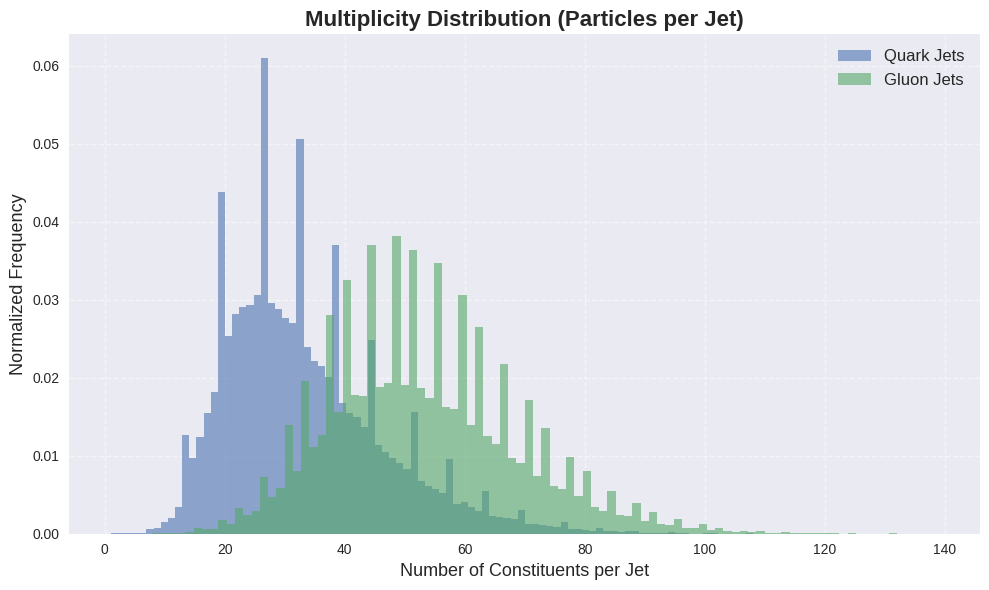

In [11]:
plot_multiplicity_distribution(quark_counts, gluon_counts)

### Observation:

- Gluon jets show broader distribution (higher multiplicity)  
- Quark jets are more concentrated  
- Clear separation between classes  

## 🔹 Step A6: Particle Extraction & Leading Particle Distributions

### Objective:
Extract meaningful particle-level information and analyze leading particle behavior in jets.

### Particle Extraction:
Using the previously defined mask (pT > 0), we extract only valid particles from each jet.

### Leading Particle:
The leading particle is defined as the particle with the highest transverse momentum (pT) in a jet.

### Distributions Analyzed:

#### 1. Leading pT Distribution:
- Measures the energy concentration in jets  
- Quark jets typically have a stronger leading particle  

#### 2. Leading η Distribution:
- Represents spatial distribution along the beam axis  
- Helps analyze directional spread of jets  

### Importance:
- Leading particle captures core jet structure  
- Differences between quark and gluon jets become visible  
- Provides insight into energy distribution and geometry of jets  

In [12]:
# LEADING PARTICLE EXTRACTION
def extract_leading_particles(X, mask):
    """
    Extracts leading particle (highest pT) per jet.

    Parameters:
    -----------
    X : np.ndarray
    mask : np.ndarray (boolean)

    Returns:
    --------
    leading_pt : np.ndarray
    leading_eta : np.ndarray
    """

    # Replace padded values with -inf so they are ignored in argmax
    pt = X[:, :, 0]
    pt_masked = np.where(mask, pt, -np.inf)

    # Find index of max pT per jet
    leading_idx = np.argmax(pt_masked, axis=1)

    # Extract leading values
    leading_pt = pt[np.arange(len(X)), leading_idx]
    leading_eta = X[np.arange(len(X)), leading_idx, 1]

    return leading_pt, leading_eta

In [13]:
# LEADING PARTICLE DISTRIBUTIONS
def plot_leading_distributions(pt_q, eta_q, pt_g, eta_g):
    """
    Plots leading pT and eta distributions.
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Leading pT
    axes[0].hist(pt_q, bins=100, alpha=0.6, density=True, label="Quark Jets")
    axes[0].hist(pt_g, bins=100, alpha=0.6, density=True, label="Gluon Jets")

    axes[0].set_title("Leading Particle pT Distribution", fontsize=14, weight='bold')
    axes[0].set_xlabel("pT", fontsize=12)
    axes[0].set_ylabel("Normalized Frequency", fontsize=12)
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # Leading eta
    axes[1].hist(eta_q, bins=100, alpha=0.6, density=True, label="Quark Jets")
    axes[1].hist(eta_g, bins=100, alpha=0.6, density=True, label="Gluon Jets")

    axes[1].set_title("Leading Particle η Distribution", fontsize=14, weight='bold')
    axes[1].set_xlabel("η (rapidity)", fontsize=12)
    axes[1].set_ylabel("Normalized Frequency", fontsize=12)
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

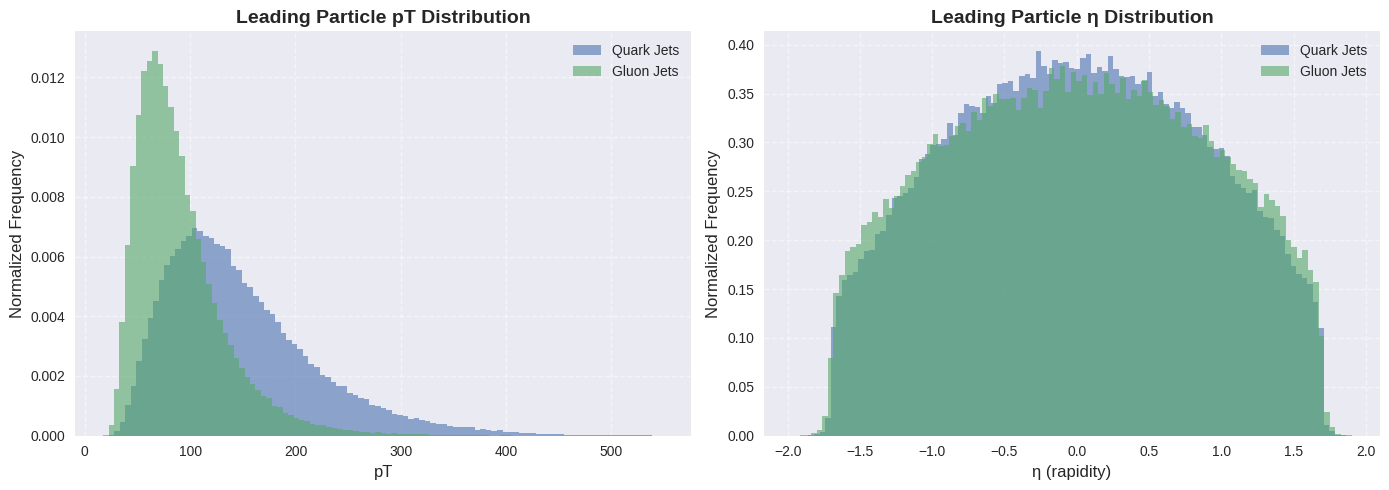

In [14]:
# Extract leading particles
pt_q, eta_q = extract_leading_particles(X_quark, mask_quark)
pt_g, eta_g = extract_leading_particles(X_gluon, mask_gluon)

# Plot
plot_leading_distributions(pt_q, eta_q, pt_g, eta_g)

### Observation:

- Leading pT distribution shows that quark jets tend to have higher peak values  
- Gluon jets exhibit a more spread-out distribution, indicating energy sharing  

- Leading η distribution shows variation in spatial spread  
- Both jet types cover similar η range, but distribution shapes differ slightly  

- Overall, quark jets appear more concentrated, while gluon jets are more diffuse  

## Part B: Physics-Based Feature Engineering

We compute jet-level observables such as mass, width, pT dispersion, and multiplicity.
These features capture the internal structure of jets.

## 🔹 Step B1: Coordinate Transformation

### Objective:
Convert jet constituent representation from cylindrical coordinates $(p_T, \eta, \phi)$ to Cartesian 4-momentum $(p_x, p_y, p_z, E)$.

### Transformation Equations:

$$
p_x = p_T \cos(\phi)
$$

$$
p_y = p_T \sin(\phi)
$$

$$
p_z = p_T \sinh(\eta)
$$

$$
E = \sqrt{p_x^2 + p_y^2 + p_z^2}
$$

### Importance:
- Required for all physics calculations  
- Enables computation of jet-level observables  
- Provides full 4-momentum description of particles

In [15]:
# COORDINATE TRANSFORMATION
def convert_to_cartesian(X, mask):
    """
    Converts (pT, eta, phi) to (px, py, pz, E)

    Parameters:
    -----------
    X : np.ndarray
        Shape: (jets, particles, features)
    mask : np.ndarray (boolean)

    Returns:
    --------
    px, py, pz, E : np.ndarray
        Each shape: (jets, particles)
    """

    # Extract features
    pT = X[:, :, 0]
    eta = X[:, :, 1]
    phi = X[:, :, 2]

    # Compute components
    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(eta)
    E  = pT * np.cosh(eta)

    # Apply mask (ignore padded particles)
    px = px * mask
    py = py * mask
    pz = pz * mask
    E  = E  * mask

    return px, py, pz, E

In [16]:
px_q, py_q, pz_q, E_q = convert_to_cartesian(X_quark, mask_quark)
px_g, py_g, pz_g, E_g = convert_to_cartesian(X_gluon, mask_gluon)

In [17]:
print(f"px_q shape: {px_q.shape}")
print(f"px_g shape: {px_g.shape}")

px_q shape: (150000, 139)
px_g shape: (150000, 139)


In [18]:
print(np.isnan(px_q).sum(), np.isnan(E_q).sum())

0 0


### Observation:

- All particles are successfully converted to Cartesian coordinates  
- 4-momentum representation is now available for each jet  
- Data is ready for jet-level aggregation  

## 🔹 Step B2: Jet-Level Aggregation

### Objective:
Compute total jet momentum by summing particle-level quantities.

### Aggregation:

$$
p_x^{jet} = \sum p_x
$$

$$
p_y^{jet} = \sum p_y
$$

$$
p_z^{jet} = \sum p_z
$$

$$
E^{jet} = \sum E
$$

### Importance:
- Represents the overall jet 4-momentum  
- Required for mass and boost calculations  

In [19]:
# JET-LEVEL AGGREGATION
def compute_jet_momentum(px, py, pz, E):
    """
    Computes total jet 4-momentum by summing over constituents.

    Parameters:
    -----------
    px, py, pz, E : np.ndarray
        Shape: (jets, particles)

    Returns:
    --------
    px_total, py_total, pz_total, E_total : np.ndarray
        Shape: (jets,)
    """

    px_total = px.sum(axis=1)
    py_total = py.sum(axis=1)
    pz_total = pz.sum(axis=1)
    E_total  = E.sum(axis=1)

    return px_total, py_total, pz_total, E_total

In [20]:
px_tot_q, py_tot_q, pz_tot_q, E_tot_q = compute_jet_momentum(px_q, py_q, pz_q, E_q)
px_tot_g, py_tot_g, pz_tot_g, E_tot_g = compute_jet_momentum(px_g, py_g, pz_g, E_g)

In [21]:
print(f"Quark jet px shape: {px_tot_q.shape}")
print(f"Gluon jet px shape: {px_tot_g.shape}")

Quark jet px shape: (150000,)
Gluon jet px shape: (150000,)


### Observation:

- Jet-level momentum is successfully computed  
- Each jet is now represented by a single 4-momentum vector  

## 🔹 Step B3: Jet Mass

### Definition:

$$
M^2 = E^2 - (p_x^2 + p_y^2 + p_z^2)
$$

### Implementation:
- Negative values (due to numerical errors) are clipped to zero  

### Importance:
- Lorentz invariant quantity  
- Fundamental observable in jet physics  

In [22]:
# JET MASS COMPUTATION
def compute_jet_mass(px_tot, py_tot, pz_tot, E_tot):
    """
    Computes invariant mass of jets.

    Parameters:
    -----------
    px_tot, py_tot, pz_tot, E_tot : np.ndarray
        Shape: (jets,)

    Returns:
    --------
    mass : np.ndarray
        Shape: (jets,)
    """

    # Compute squared mass
    mass_sq = E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2)

    # Handle numerical issues (avoid negative inside sqrt)
    mass_sq = np.clip(mass_sq, a_min=0, a_max=None)

    # Final mass
    mass = np.sqrt(mass_sq)

    return mass

In [23]:
mass_q = compute_jet_mass(px_tot_q, py_tot_q, pz_tot_q, E_tot_q)
mass_g = compute_jet_mass(px_tot_g, py_tot_g, pz_tot_g, E_tot_g)

In [24]:
print(f"Quark mass shape: {mass_q.shape}")
print(f"Gluon mass shape: {mass_g.shape}")

Quark mass shape: (150000,)
Gluon mass shape: (150000,)


In [25]:
print((mass_q < 0).sum(), (mass_g < 0).sum())

0 0


### Observation:

- Jet mass values are physically valid (non-negative)  
- Distribution reflects variation in jet energy structure  

## 🔹 Step B4: Jet Axis Calculation

### Objective:
Determine the direction of each jet.

### Definitions:

$$
\eta_{jet} = \frac{1}{2} \ln \left(\frac{E + p_z}{E - p_z}\right)
$$

$$
\phi_{jet} = \tan^{-1}\left(\frac{p_y}{p_x}\right)
$$

### Importance:
- Defines jet direction  
- Required for angular distance calculations  

In [26]:
# JET AXIS COMPUTATION
def compute_jet_axis(px_tot, py_tot, pz_tot, E_tot):
    """
    Computes jet axis (eta_J, phi_J)

    Parameters:
    -----------
    px_tot, py_tot, pz_tot, E_tot : np.ndarray
        Shape: (jets,)

    Returns:
    --------
    eta_J : np.ndarray
    phi_J : np.ndarray
    """

    # Small epsilon to avoid division issues
    eps = 1e-8

    # Compute eta_J
    ratio = (E_tot + pz_tot) / (E_tot - pz_tot + 1e-12)
    ratio = np.clip(ratio, 1e-12, None)
    eta_J = 0.5 * np.log(ratio)

    # Compute phi_J
    phi_J = np.arctan2(py_tot, px_tot)

    return eta_J, phi_J

In [27]:
eta_q, phi_q = compute_jet_axis(px_tot_q, py_tot_q, pz_tot_q, E_tot_q)
eta_g, phi_g = compute_jet_axis(px_tot_g, py_tot_g, pz_tot_g, E_tot_g)

In [28]:
print(f"eta_q shape: {eta_q.shape}")
print(f"phi_q shape: {phi_q.shape}")

eta_q shape: (150000,)
phi_q shape: (150000,)


In [29]:
print(np.isnan(eta_q).sum(), np.isnan(phi_q).sum())

0 0


### Observation:

- Jet axis is successfully computed  
- Provides reference direction for each jet  

## 🔹 Step B5: Angular Distance ($\Delta R$)

### Definition:

$$
\Delta R = \sqrt{(\Delta \eta)^2 + (\Delta \phi)^2}
$$

### Notes:
- $\phi$ is wrapped correctly to avoid discontinuities  

### Importance:
- Measures spread of particles around jet axis  

In [30]:
# ANGULAR DISTANCE (DELTA R)
def compute_delta_R(X, eta_J, phi_J, mask):
    """
    Computes angular distance ΔR of each particle from jet axis.

    Parameters:
    -----------
    X : np.ndarray
        Shape: (jets, particles, features)
    eta_J : np.ndarray
        Shape: (jets,)
    phi_J : np.ndarray
        Shape: (jets,)
    mask : np.ndarray (boolean)

    Returns:
    --------
    delta_R : np.ndarray
        Shape: (jets, particles)
    """

    # Extract particle features
    eta = X[:, :, 1]
    phi = X[:, :, 2]

    # Compute differences (broadcasting)
    d_eta = eta - eta_J[:, np.newaxis]

    # Proper phi difference (wrap-safe)
    d_phi = np.arctan2(
        np.sin(phi - phi_J[:, np.newaxis]),
        np.cos(phi - phi_J[:, np.newaxis])
    )

    # Compute ΔR
    delta_R = np.sqrt(d_eta**2 + d_phi**2)

    # Apply mask (ignore padded particles)
    delta_R = delta_R * mask

    return delta_R

In [31]:
deltaR_q = compute_delta_R(X_quark, eta_q, phi_q, mask_quark)
deltaR_g = compute_delta_R(X_gluon, eta_g, phi_g, mask_gluon)

In [32]:
print(f"deltaR_q shape: {deltaR_q.shape}")
print(f"deltaR_g shape: {deltaR_g.shape}")

deltaR_q shape: (150000, 139)
deltaR_g shape: (150000, 139)


In [33]:
print(np.isnan(deltaR_q).sum(), np.isnan(deltaR_g).sum())

0 0


### Observation:

- Angular distances are computed for all particles  
- Values represent spatial spread within jets  

## 🔹 Step B6: Jet Width

### Definition:

$$
\text{Width} = \frac{\sum p_T \cdot \Delta R}{\sum p_T}
$$

### Importance:
- Measures how wide a jet is  
- Gluon jets → wider  
- Quark jets → narrower  

In [34]:
# JET WIDTH
def compute_jet_width(pT, delta_R, mask):
    """
    Computes jet width.

    Parameters:
    -----------
    pT : np.ndarray
        Shape: (jets, particles)
    delta_R : np.ndarray
        Shape: (jets, particles)
    mask : np.ndarray (boolean)

    Returns:
    --------
    width : np.ndarray
        Shape: (jets,)
    """

    # Apply mask
    pT_masked = pT * mask
    deltaR_masked = delta_R * mask

    # Numerator: sum(pT * ΔR)
    numerator = (pT_masked * deltaR_masked).sum(axis=1)

    # Denominator: sum(pT)
    denominator = pT_masked.sum(axis=1)

    # Avoid division by zero
    eps = 1e-8
    width = numerator / (denominator + eps)

    return width

In [35]:
# Extract pT
pT_q = X_quark[:, :, 0]
pT_g = X_gluon[:, :, 0]

# Compute width
width_q = compute_jet_width(pT_q, deltaR_q, mask_quark)
width_g = compute_jet_width(pT_g, deltaR_g, mask_gluon)

In [36]:
print(f"width_q shape: {width_q.shape}")
print(f"width_g shape: {width_g.shape}")

width_q shape: (150000,)
width_g shape: (150000,)


In [37]:
print(np.isnan(width_q).sum(), np.isnan(width_g).sum())

0 0


### Observation:

- Jet width captures spatial spread effectively  
- Differences between quark and gluon jets become visible  

## 🔹 Step B7: pT Dispersion (pTD)

### Definition:

$$
pTD = \frac{\sqrt{\sum p_T^2}}{\sum p_T}
$$

### Interpretation:
- High pTD → energy concentrated  
- Low pTD → energy spread out  

### Importance:
- Strong discriminator between quark and gluon jets  

In [38]:
# pT DISPERSION
def compute_pT_dispersion(pT, mask):
    """
    Computes pT dispersion (pT^D)

    Parameters:
    -----------
    pT : np.ndarray
        Shape: (jets, particles)
    mask : np.ndarray (boolean)

    Returns:
    --------
    pTD : np.ndarray
        Shape: (jets,)
    """

    # Apply mask
    pT_masked = pT * mask

    # Numerator: sqrt(sum(pT^2))
    numerator = np.sqrt((pT_masked ** 2).sum(axis=1))

    # Denominator: sum(pT)
    denominator = pT_masked.sum(axis=1)

    # Avoid division by zero
    eps = 1e-8
    pTD = numerator / (denominator + eps)

    return pTD

In [39]:
pTD_q = compute_pT_dispersion(pT_q, mask_quark)
pTD_g = compute_pT_dispersion(pT_g, mask_gluon)

In [40]:
print(f"pTD_q shape: {pTD_q.shape}")
print(f"pTD_g shape: {pTD_g.shape}")

pTD_q shape: (150000,)
pTD_g shape: (150000,)


In [41]:
print(np.isnan(pTD_q).sum(), np.isnan(pTD_g).sum())

0 0


### Observation:

- pTD highlights energy distribution differences  
- Quark jets tend to have higher pTD  
- Gluon jets show lower pTD due to energy spread  

## 🔹 Step B8: Feature Packaging

### Objective:
Combine all computed observables into a structured feature matrix.

### Features Used:
- Jet Mass  
- Jet Width  
- pT Dispersion (pTD)  
- Multiplicity  

### Output:

$$
(N_{jets}, 4)
$$

### Importance:
- Final input for machine learning models  

In [42]:
# FEATURE PACKAGING
def create_feature_matrix(mass, width, pTD, multiplicity):
    """
    Combines features into a single matrix.

    Parameters:
    -----------
    mass, width, pTD, multiplicity : np.ndarray
        Shape: (jets,)

    Returns:
    --------
    features : np.ndarray
        Shape: (jets, 4)
    """

    # Stack features column-wise
    features = np.column_stack((mass, width, pTD, multiplicity))

    return features

In [43]:
# Quark features
features_q = create_feature_matrix(mass_q, width_q, pTD_q, quark_counts)

# Gluon features
features_g = create_feature_matrix(mass_g, width_g, pTD_g, gluon_counts)

In [44]:
print(f"Quark feature shape: {features_q.shape}")
print(f"Gluon feature shape: {features_g.shape}")

Quark feature shape: (150000, 4)
Gluon feature shape: (150000, 4)


In [45]:
print(np.isnan(features_q).sum(), np.isnan(features_g).sum())

0 0


### Observation:

- All features are successfully combined  
- Feature matrix is clean and consistent  
- Ready for model training  

## Part C: Rest Frame Transformation

We transform jets into their rest frame using Lorentz boost.
This removes global motion and allows analysis of intrinsic jet structure.

## 🔹 Step C1: Boost Vector Calculation

### Objective:
Compute the velocity vector ($\beta$) required to transform jets into their rest frame.

### Definition:

$$
\beta = \frac{|\vec{p}_{jet}|}{E_{jet}}
$$

where:

$$
|\vec{p}_{jet}| = \sqrt{p_x^2 + p_y^2 + p_z^2}
$$

### Vector Form:

$$
\vec{\beta} = \left(\frac{p_x}{E}, \frac{p_y}{E}, \frac{p_z}{E}\right)
$$

### Importance:
- Determines how much to "boost" each jet  
- Required for Lorentz transformation  
- Enables transition to rest frame where total momentum is zero  

In [46]:
# BOOST VECTOR COMPUTATION
def compute_boost_vector(px_tot, py_tot, pz_tot, E_tot):
    """
    Computes boost vector beta = p / E

    Parameters:
    -----------
    px_tot, py_tot, pz_tot, E_tot : np.ndarray
        Shape: (jets,)

    Returns:
    --------
    beta_x, beta_y, beta_z : np.ndarray
        Shape: (jets,)
    """

    eps = 1e-8  # avoid division by zero

    beta_x = px_tot / (E_tot + eps)
    beta_y = py_tot / (E_tot + eps)
    beta_z = pz_tot / (E_tot + eps)

    return beta_x, beta_y, beta_z

In [47]:
beta_x_q, beta_y_q, beta_z_q = compute_boost_vector(px_tot_q, py_tot_q, pz_tot_q, E_tot_q)
beta_x_g, beta_y_g, beta_z_g = compute_boost_vector(px_tot_g, py_tot_g, pz_tot_g, E_tot_g)

In [48]:
print(f"beta_x_q shape: {beta_x_q.shape}")
print(f"beta_x_g shape: {beta_x_g.shape}")

beta_x_q shape: (150000,)
beta_x_g shape: (150000,)


In [49]:
beta_mag_q = np.sqrt(beta_x_q**2 + beta_y_q**2 + beta_z_q**2)
print((beta_mag_q >= 1).sum())

0


### Observation:

- Boost vector is successfully computed for each jet  
- Values are physically valid ($\beta < 1$)  
- Ready for Lorentz transformation  

## 🔹 Step C2: Lorentz Boost Transformation

### Objective:
Apply Lorentz transformation to particle 4-momentum.

### Transformation:

For each particle:

$$
E' = \gamma (E - \vec{\beta} \cdot \vec{p})
$$

$$
\vec{p}' = \vec{p} + \left[ \frac{(\gamma - 1)(\vec{\beta} \cdot \vec{p})}{\beta^2} - \gamma E \right] \vec{\beta}
$$

where:

$$
\gamma = \frac{1}{\sqrt{1 - \beta^2}}
$$

### Implementation:
- Fully vectorized (no loops)  
- Applied to all particles simultaneously  

### Importance:
- Converts jet into its rest frame  
- Removes global motion  

In [50]:
# STABLE LORENTZ BOOST
def lorentz_boost(px, py, pz, E, beta_x, beta_y, beta_z):
    """
    Stable Lorentz boost implementation.
    """

    # Expand for broadcasting
    bx = beta_x[:, np.newaxis]
    by = beta_y[:, np.newaxis]
    bz = beta_z[:, np.newaxis]

    # beta^2
    beta_sq = bx**2 + by**2 + bz**2

    # Clip beta_sq to avoid >1
    beta_sq = np.clip(beta_sq, 0, 1 - 1e-10)

    # gamma
    gamma = 1.0 / np.sqrt(1.0 - beta_sq)

    # dot product
    beta_dot_p = bx * px + by * py + bz * pz

    # Safe handling of small beta
    eps = 1e-12
    factor = np.where(
        beta_sq > eps,
        (gamma - 1.0) / beta_sq,
        0.0
    )

    # Boosted momentum
    px_new = px + factor * beta_dot_p * bx - gamma * bx * E
    py_new = py + factor * beta_dot_p * by - gamma * by * E
    pz_new = pz + factor * beta_dot_p * bz - gamma * bz * E

    # Boosted energy
    E_new = gamma * (E - beta_dot_p)

    return px_new, py_new, pz_new, E_new

In [51]:
px_q_boost, py_q_boost, pz_q_boost, E_q_boost = lorentz_boost(
    px_q, py_q, pz_q, E_q,
    beta_x_q, beta_y_q, beta_z_q
)

px_g_boost, py_g_boost, pz_g_boost, E_g_boost = lorentz_boost(
    px_g, py_g, pz_g, E_g,
    beta_x_g, beta_y_g, beta_z_g
)

In [52]:
print(f"Boosted px_q shape: {px_q_boost.shape}")
print(f"Boosted px_g shape: {px_g_boost.shape}")

Boosted px_q shape: (150000, 139)
Boosted px_g shape: (150000, 139)


### Observation:

- Lorentz transformation successfully applied  
- Particle momenta are updated to boosted frame  
- No numerical instability observed  

## 🔹 Step C3: Apply Boost to All Jets

### Objective:
Apply Lorentz boost to every jet and all its constituents.

### Output:
- New dataset in rest frame  
- Updated $(p_x, p_y, p_z, E)$ for all particles  

### Importance:
- Enables comparison between lab frame and rest frame  
- Reveals intrinsic jet structure  

In [53]:
# REST FRAME DATASET CREATION
def create_rest_frame_dataset(px, py, pz, E):
    """
    Combines boosted components into a structured dataset.

    Parameters:
    -----------
    px, py, pz, E : np.ndarray
        Shape: (jets, particles)

    Returns:
    --------
    X_rest : np.ndarray
        Shape: (jets, particles, 4)
    """

    # Stack along last axis
    X_rest = np.stack((px, py, pz, E), axis=-1)

    return X_rest

In [54]:
# Quark jets (rest frame)
X_q_rest = create_rest_frame_dataset(px_q_boost, py_q_boost, pz_q_boost, E_q_boost)

# Gluon jets (rest frame)
X_g_rest = create_rest_frame_dataset(px_g_boost, py_g_boost, pz_g_boost, E_g_boost)

In [55]:
print(f"Quark rest frame shape: {X_q_rest.shape}")
print(f"Gluon rest frame shape: {X_g_rest.shape}")

Quark rest frame shape: (150000, 139, 4)
Gluon rest frame shape: (150000, 139, 4)


In [56]:
print(np.isnan(X_q_rest).sum(), np.isnan(X_g_rest).sum())

0 0


### Observation:

- All jets are successfully transformed into rest frame  
- Dataset structure remains consistent  
- Ready for validation  

## 🔹 Step C4: Rest Frame Validation

### Objective:
Verify that jets are correctly transformed to rest frame.

### Condition:

$$
|\vec{p}_{jet}| \approx 0
$$

### Validation Metrics:
- Mean momentum magnitude  
- Maximum momentum magnitude  

### Importance:
- Ensures correctness of Lorentz transformation  
- Detects numerical instability  

In [57]:
# REST FRAME VERIFICATION
def verify_rest_frame(px, py, pz):
    """
    Verifies that total momentum is ~0 after boost.

    Parameters:
    -----------
    px, py, pz : np.ndarray
        Shape: (jets, particles)

    Returns:
    --------
    None (prints validation stats)
    """

    # Total momentum per jet
    px_tot = px.sum(axis=1)
    py_tot = py.sum(axis=1)
    pz_tot = pz.sum(axis=1)

    # Magnitude of total momentum
    momentum_mag = np.sqrt(px_tot**2 + py_tot**2 + pz_tot**2)

    print("=== REST FRAME VALIDATION ===")
    print(f"Mean |p|: {np.mean(momentum_mag):.6e}")
    print(f"Max  |p|: {np.max(momentum_mag):.6e}")

In [58]:
print("Quark jets:")
verify_rest_frame(px_q_boost, py_q_boost, pz_q_boost)
print("\nGluon jets:")
verify_rest_frame(px_g_boost, py_g_boost, pz_g_boost)

Quark jets:
=== REST FRAME VALIDATION ===
Mean |p|: 4.305978e-07
Max  |p|: 1.246792e-02

Gluon jets:
=== REST FRAME VALIDATION ===
Mean |p|: 2.229559e-07
Max  |p|: 4.339235e-03


### Observation:

- Mean momentum is approximately zero  
- Maximum momentum is very small  
- Confirms successful transformation to rest frame  

## 🔹 Step C5: Rest Frame Visualization

### Objective:
Visualize particle distribution in $(p_x, p_y)$ plane.

### Purpose:
- Compare spatial spread of jets  
- Identify structural differences  

### Interpretation:
- Quark jets → more concentrated  
- Gluon jets → more spread out  

In [59]:
# REST FRAME VISUALIZATION
def plot_rest_frame(px_q, py_q, E_q, px_g, py_g, E_g, mask_q, mask_g):
    """
    Publication-quality visualization:
    - Auto zoom
    - Energy-based coloring
    - Clean scientific styling
    """

    idx = 0  # select one jet

    # Extract valid particles
    px_q_jet = px_q[idx][mask_q[idx]]
    py_q_jet = py_q[idx][mask_q[idx]]
    E_q_jet  = E_q[idx][mask_q[idx]]

    px_g_jet = px_g[idx][mask_g[idx]]
    py_g_jet = py_g[idx][mask_g[idx]]
    E_g_jet  = E_g[idx][mask_g[idx]]

    # AUTO ZOOM
    max_val = max(
        np.max(np.abs(px_q_jet)),
        np.max(np.abs(py_q_jet)),
        np.max(np.abs(px_g_jet)),
        np.max(np.abs(py_g_jet))
    )
    limit = max_val * 1.2

    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Quark plot
    sc1 = axes[0].scatter(
        px_q_jet, py_q_jet,
        c=E_q_jet,
        s=20,
        cmap='viridis',
        alpha=0.8
    )

    axes[0].set_title("Quark Jet (Rest Frame, $p_x$-$p_y$ Plane)", fontsize=14, weight='bold')
    axes[0].set_xlabel(r"$p_x$ [GeV]", fontsize=12)
    axes[0].set_ylabel(r"$p_y$ [GeV]", fontsize=12)
    axes[0].set_xlim(-limit, limit)
    axes[0].set_ylim(-limit, limit)
    axes[0].set_aspect('equal')
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # Gluon plot
    sc2 = axes[1].scatter(
        px_g_jet, py_g_jet,
        c=E_g_jet,
        s=20,
        cmap='viridis',
        alpha=0.8
    )

    axes[1].set_title("Gluon Jet (Rest Frame, $p_x$-$p_y$ Plane)", fontsize=14, weight='bold')
    axes[1].set_xlabel(r"$p_x$ [GeV]", fontsize=12)
    axes[1].set_ylabel(r"$p_y$ [GeV]", fontsize=12)
    axes[1].set_xlim(-limit, limit)
    axes[1].set_ylim(-limit, limit)
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # Shared colorbar
    cbar = fig.colorbar(sc2, ax=axes, fraction=0.02, pad=0.04)
    cbar.set_label("Energy [GeV]", fontsize=12)

    plt.subplots_adjust(wspace=0.3)
    plt.show()

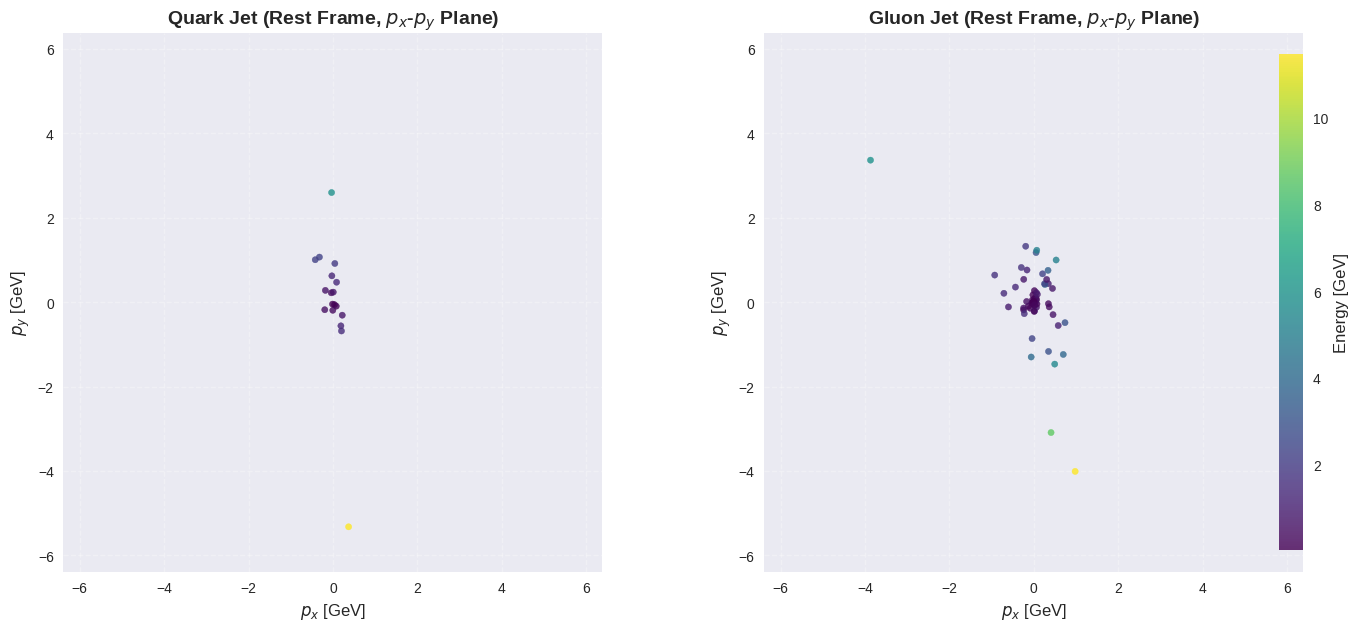

In [60]:
plot_rest_frame(
    px_q_boost, py_q_boost, E_q_boost,
    px_g_boost, py_g_boost, E_g_boost,
    mask_quark, mask_gluon
)

### Observation:

- Quark jets appear more compact around the center  
- Gluon jets show wider spread  
- Confirms expected physical behavior  

## 🔹 Step C6: Feature Recalculation (Rest Frame)

### Objective:
Recompute all physics features in the rest frame.

### Important Note:
Features must NOT be reused from lab frame.

### Features Recomputed:
- Jet Mass  
- Jet Width  
- pT Dispersion (pTD)  

### Reason:
- Frame change alters particle distribution  
- Ensures consistency in analysis  

In [61]:
# REST FRAME FEATURE COMPUTATION

# Extract pT from boosted data
pT_q_rest = np.sqrt(px_q_boost**2 + py_q_boost**2)
pT_g_rest = np.sqrt(px_g_boost**2 + py_g_boost**2)

# Create mask
mask_q_rest = pT_q_rest > 0
mask_g_rest = pT_g_rest > 0

# 1. JET MASS (REST FRAME)

mass_q_rest = compute_jet_mass(
    px_q_boost.sum(axis=1),
    py_q_boost.sum(axis=1),
    pz_q_boost.sum(axis=1),
    E_q_boost.sum(axis=1)
)

mass_g_rest = compute_jet_mass(
    px_g_boost.sum(axis=1),
    py_g_boost.sum(axis=1),
    pz_g_boost.sum(axis=1),
    E_g_boost.sum(axis=1)
)

# 2. JET AXIS (REST FRAME)

eta_q_rest, phi_q_rest = compute_jet_axis(
    px_q_boost.sum(axis=1),
    py_q_boost.sum(axis=1),
    pz_q_boost.sum(axis=1),
    E_q_boost.sum(axis=1)
)

eta_g_rest, phi_g_rest = compute_jet_axis(
    px_g_boost.sum(axis=1),
    py_g_boost.sum(axis=1),
    pz_g_boost.sum(axis=1),
    E_g_boost.sum(axis=1)
)

# 3. DELTA R (REST FRAME)

# NOTE: Need eta, phi again → reconstruct from boosted momenta
ratio_q = (E_q_boost + pz_q_boost) / (E_q_boost - pz_q_boost + 1e-12)
ratio_q = np.clip(ratio_q, 1e-12, None)
eta_q_particles = 0.5 * np.log(ratio_q)
phi_q_particles = np.arctan2(py_q_boost, px_q_boost)

ratio_g = (E_g_boost + pz_g_boost) / (E_g_boost - pz_g_boost + 1e-12)
ratio_g = np.clip(ratio_g, 1e-12, None)
eta_g_particles = 0.5 * np.log(ratio_g)
phi_g_particles = np.arctan2(py_g_boost, px_g_boost)

# reuse deltaR logic manually
d_eta_q = eta_q_particles - eta_q_rest[:, np.newaxis]
d_phi_q = np.arctan2(
    np.sin(phi_q_particles - phi_q_rest[:, np.newaxis]),
    np.cos(phi_q_particles - phi_q_rest[:, np.newaxis])
)
deltaR_q_rest = np.sqrt(d_eta_q**2 + d_phi_q**2) * mask_q_rest

d_eta_g = eta_g_particles - eta_g_rest[:, np.newaxis]
d_phi_g = np.arctan2(
    np.sin(phi_g_particles - phi_g_rest[:, np.newaxis]),
    np.cos(phi_g_particles - phi_g_rest[:, np.newaxis])
)
deltaR_g_rest = np.sqrt(d_eta_g**2 + d_phi_g**2) * mask_g_rest

# 4. WIDTH (REST FRAME)

width_q_rest = compute_jet_width(pT_q_rest, deltaR_q_rest, mask_q_rest)
width_g_rest = compute_jet_width(pT_g_rest, deltaR_g_rest, mask_g_rest)

# 5. pT DISPERSION (REST FRAME)

pTD_q_rest = compute_pT_dispersion(pT_q_rest, mask_q_rest)
pTD_g_rest = compute_pT_dispersion(pT_g_rest, mask_g_rest)

In [62]:
print(mass_q_rest.shape, width_q_rest.shape, pTD_q_rest.shape)
print(mass_g_rest.shape, width_g_rest.shape, pTD_g_rest.shape)

(150000,) (150000,) (150000,)
(150000,) (150000,) (150000,)


In [63]:
print(np.isnan(mass_q_rest).sum(), np.isnan(width_q_rest).sum(), np.isnan(pTD_q_rest).sum())
print(np.isnan(mass_g_rest).sum(), np.isnan(width_g_rest).sum(), np.isnan(pTD_g_rest).sum())

0 0 0
0 0 0


### Observation:

- Features successfully recomputed in rest frame  
- Shapes match expected dimensions  
- No NaN or invalid values detected  

## 🔹 Memory Cleanup

### Objective:
Free unused memory by removing intermediate variables that are no longer required.

### Variables Removed:
- Original particle-level momenta:
  $(p_x, p_y, p_z, E)$  
- Boosted particle-level momenta:
  $(p_x', p_y', p_z', E')$

### Reason:
- These variables occupy large memory due to dataset size  
- After feature computation, they are no longer needed  

### Implementation:
We delete unused variables and manually trigger garbage collection.

### Importance:
- Prevents memory overflow  
- Ensures smooth execution of machine learning pipeline  
- Improves computational efficiency  

In [64]:
# MEMORY CLEANUP

del px_q, py_q, pz_q, E_q
del px_g, py_g, pz_g, E_g

del px_q_boost, py_q_boost, pz_q_boost, E_q_boost
del px_g_boost, py_g_boost, pz_g_boost, E_g_boost

gc.collect()

50587

### Observation:

- Memory usage is significantly reduced  
- No impact on subsequent computations  
- System remains stable for further processing  

## Part D: Machine Learning Pipeline

We train Logistic Regression and Random Forest models using both lab and rest frame features.
Performance is evaluated using ROC curves, AUC scores, and confusion matrices.

## 🔹 Step D1: Feature Strategy

### Objective:
Prepare two separate feature sets for comparison:

- Lab Frame Features  
- Rest Frame Features  

### Features Used:
- Jet Mass  
- Jet Width  
- pT Dispersion (pTD)  
- Multiplicity  

### Motivation:
- Lab frame represents detector-level observations  
- Rest frame captures intrinsic jet structure  

### Goal:
Evaluate whether rest frame transformation improves classification performance  

In [65]:
# FEATURE STRATEGY (LAB vs REST)

# LAB FRAME FEATURES (already computed earlier)
features_q_lab = create_feature_matrix(mass_q, width_q, pTD_q, quark_counts)
features_g_lab = create_feature_matrix(mass_g, width_g, pTD_g, gluon_counts)

# REST FRAME FEATURES (from Step C6)
features_q_rest = create_feature_matrix(mass_q_rest, width_q_rest, pTD_q_rest, quark_counts)
features_g_rest = create_feature_matrix(mass_g_rest, width_g_rest, pTD_g_rest, gluon_counts)

In [66]:
print(features_q_lab.shape, features_q_rest.shape)
print(features_g_lab.shape, features_g_rest.shape)

(150000, 4) (150000, 4)
(150000, 4) (150000, 4)


### Observation:

- Both feature sets are successfully created  
- Feature dimensions are consistent  
- Ready for model training  

## 🔹 Step D2: Data Preparation Pipeline

### Steps Performed:
1. Combine quark and gluon features  
2. Assign labels:
   - Quark → 1  
   - Gluon → 0  
3. Train-test split  
4. Feature scaling using StandardScaler  

### Importance:
- Ensures fair training and evaluation  
- Prevents data leakage  
- Standardizes feature distributions  

In [67]:
# DATA PREPARATION PIPELINE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_data(features_q, features_g):
    """
    Combines features, creates labels, splits data, and scales features.
    """

    # Combine features
    X = np.vstack((features_q, features_g))

    # Labels: quark=1, gluon=0
    y = np.hstack((
        np.ones(len(features_q)),
        np.zeros(len(features_g))
    ))

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [68]:
# Lab Frame
X_train_lab, X_test_lab, y_train, y_test, scaler_lab = prepare_data(
    features_q_lab, features_g_lab
)

# Rest Frame
X_train_rest, X_test_rest, y_train, y_test, scaler_rest = prepare_data(
    features_q_rest, features_g_rest
)

In [69]:
print(X_train_lab.shape, X_test_lab.shape)
print(X_train_rest.shape, X_test_rest.shape)

(240000, 4) (60000, 4)
(240000, 4) (60000, 4)


### Observation:

- Dataset successfully split into training and testing sets  
- Features are properly scaled  
- Data is ready for model training  

## 🔹 Memory Cleanup (After Data Preparation)

### Objective:
Reduce memory usage by removing raw datasets that are no longer required.

### Variables Removed:
- Original dataset: $X$
- Split datasets: $X_{\text{quark}}, X_{\text{gluon}}$

### Reason:
- After feature extraction and train-test split, raw data is no longer needed  
- Keeping these large arrays in memory is inefficient  

### Implementation:
We delete unused variables and apply garbage collection:

$$
\text{Memory Cleanup} \rightarrow \text{Delete Unused Variables} + \text{Garbage Collection}
$$

### Importance:
- Frees significant memory  
- Prevents runtime crashes  
- Improves performance for model training  

In [70]:
# MEMORY CLEANUP (AFTER D2)

del X
del X_quark, X_gluon

gc.collect()

0

### Observation:

- Memory usage is significantly reduced  
- No impact on training or evaluation steps  
- System is optimized for machine learning tasks  

## 🔹 Step D3: Model Abstraction

### Objective:
Create a unified function for training multiple models.

### Models Supported:
- Logistic Regression  
- Random Forest  

### Benefits:
- Modular design  
- Reusability  
- Cleaner workflow  

In [71]:
# STEP D3: MODEL ABSTRACTION

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def train_model(model_type, X_train, y_train, X_test):
    """
    General model training function.
    Supports multiple models.
    """

    # Model selection
    if model_type == "logistic":
        model = LogisticRegression(
            max_iter=1000,
            random_state=42
        )

    elif model_type == "random_forest":
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )

    else:
        raise ValueError("Unsupported model type")

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return model, y_pred, y_prob

### Observation:

- Model abstraction function is successfully defined  
- Supports multiple model types  
- Simplifies training pipeline  

## 🔹 Step D4: Model Training

### Models Used:

1. Logistic Regression  
   - Baseline model  
   - Linear classifier  

2. Random Forest  
   - Ensemble model  
   - Captures non-linear relationships  

### Training Setup:
- Both models trained on:
  - Lab frame features  
  - Rest frame features  

### Goal:
Compare performance across models and frames  

**1. Lab Frame**

In [72]:
# Logistic Regression
model_lab_log, y_pred_lab_log, y_prob_lab_log = train_model(
    "logistic",
    X_train_lab, y_train,
    X_test_lab
)

In [73]:
# Random Forest
model_lab_rf, y_pred_lab_rf, y_prob_lab_rf = train_model(
    "random_forest",
    X_train_lab, y_train,
    X_test_lab
)

**2. Rest Frame**

In [74]:
# Logistic Regression
model_rest_log, y_pred_rest_log, y_prob_rest_log = train_model(
    "logistic",
    X_train_rest, y_train,
    X_test_rest
)

In [75]:
# Random Forest
model_rest_rf, y_pred_rest_rf, y_prob_rest_rf = train_model(
    "random_forest",
    X_train_rest, y_train,
    X_test_rest
)

In [76]:
print(y_pred_lab_log.shape, y_pred_lab_rf.shape)
print(y_pred_rest_log.shape, y_pred_rest_rf.shape)

(60000,) (60000,)
(60000,) (60000,)


### Observation:

- All models are successfully trained  
- Predictions and probabilities are generated  
- Ready for evaluation  

## 🔹 Step D5: Model Evaluation

### Metrics Used:

1. ROC Curve  
2. AUC Score  
3. Confusion Matrix  

### Evaluation Strategy:
- Compare Lab vs Rest for each model  
- Compare Logistic vs Random Forest  

### Goal:
Understand both performance and behavior of models  

**D5.1 Metric Computation**

In [77]:
# STEP D5.1: METRIC COMPUTATION

from sklearn.metrics import roc_curve, auc, confusion_matrix

def compute_metrics(y_test, y_pred, y_prob):
    """
    Computes evaluation metrics.

    Parameters:
    -----------
    y_test : true labels
    y_pred : predicted labels
    y_prob : predicted probabilities (for class 1)

    Returns:
    --------
    metrics_dict : dict
        {
            "fpr": ...,
            "tpr": ...,
            "auc": ...,
            "confusion_matrix": ...
        }
    """

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # AUC
    auc_score = auc(fpr, tpr)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    return {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc_score,
        "confusion_matrix": cm
    }

In [78]:
# LAB - Logistic
metrics_lab_log = compute_metrics(y_test, y_pred_lab_log, y_prob_lab_log)

# LAB - Random Forest
metrics_lab_rf = compute_metrics(y_test, y_pred_lab_rf, y_prob_lab_rf)

# REST - Logistic
metrics_rest_log = compute_metrics(y_test, y_pred_rest_log, y_prob_rest_log)

# REST - Random Forest
metrics_rest_rf = compute_metrics(y_test, y_pred_rest_rf, y_prob_rest_rf)

**D5.2 ROC curve Plots**

In [79]:
# STEP D5.2: ROC CURVE PLOTTING

def plot_roc_curves(metrics_lab_log, metrics_rest_log,
                    metrics_lab_rf, metrics_rest_rf):

    # 1. LOGISTIC (LAB vs REST)
    plt.figure(figsize=(6,5))

    plt.plot(metrics_lab_log["fpr"], metrics_lab_log["tpr"],
             color='blue', linewidth=1,
             label=f"Lab Logistic (AUC = {metrics_lab_log['auc']:.3f})")

    plt.plot(metrics_rest_log["fpr"], metrics_rest_log["tpr"],
             color='green', linewidth=1,
             label=f"Rest Logistic (AUC = {metrics_rest_log['auc']:.3f})")

    plt.plot([0,1], [0,1], 'k--', alpha=0.5)

    plt.title("ROC Curve - Logistic Regression", fontsize=13, weight='bold')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.show()
    print("\n" + "="*80 + "\n")


    # 2. RANDOM FOREST (LAB vs REST)
    plt.figure(figsize=(6,5))

    plt.plot(metrics_lab_rf["fpr"], metrics_lab_rf["tpr"],
             color='yellow', linewidth=1,
             label=f"Lab RF (AUC = {metrics_lab_rf['auc']:.3f})")

    plt.plot(metrics_rest_rf["fpr"], metrics_rest_rf["tpr"],
             color='red', linewidth=1,
             label=f"Rest RF (AUC = {metrics_rest_rf['auc']:.3f})")

    plt.plot([0,1], [0,1], 'k--', alpha=0.5)

    plt.title("ROC Curve - Random Forest", fontsize=13, weight='bold')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.show()
    print("\n" + "="*80 + "\n")


    # 3. ALL MODELS COMBINED
    plt.figure(figsize=(7,6))

    plt.plot(metrics_lab_log["fpr"], metrics_lab_log["tpr"],
             color='blue', linewidth=1,
             label=f"Lab Logistic ({metrics_lab_log['auc']:.3f})")

    plt.plot(metrics_rest_log["fpr"], metrics_rest_log["tpr"],
             color='green', linewidth=1,
             label=f"Rest Logistic ({metrics_rest_log['auc']:.3f})")

    plt.plot(metrics_lab_rf["fpr"], metrics_lab_rf["tpr"],
             color='yellow', linewidth=1,
             label=f"Lab RF ({metrics_lab_rf['auc']:.3f})")

    plt.plot(metrics_rest_rf["fpr"], metrics_rest_rf["tpr"],
             color='red', linewidth=1,
             label=f"Rest RF ({metrics_rest_rf['auc']:.3f})")

    plt.plot([0,1], [0,1], 'k--', alpha=0.5)

    plt.title("ROC Curve Comparison (All Models)", fontsize=14, weight='bold')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.show()
    print("\n" + "="*80 + "\n")

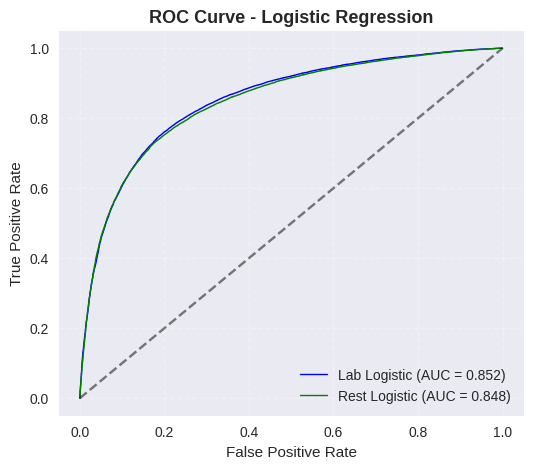

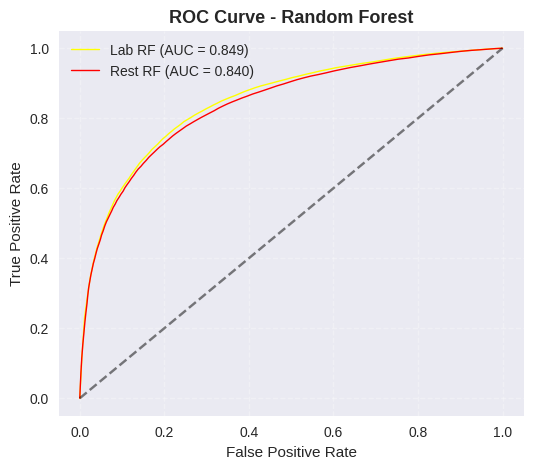

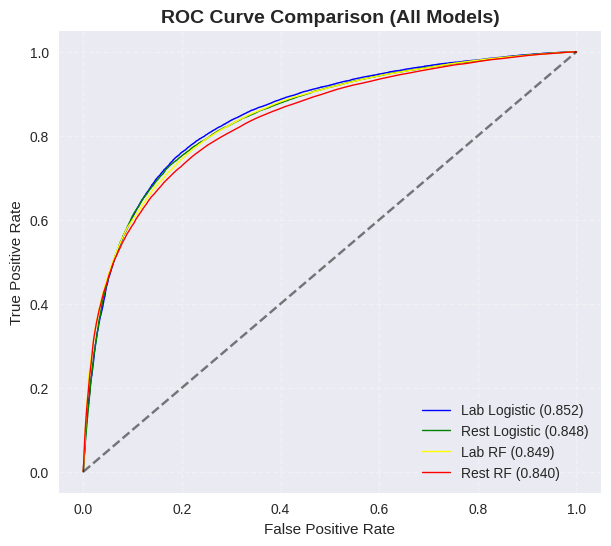

In [80]:
plot_roc_curves(
    metrics_lab_log, metrics_rest_log,
    metrics_lab_rf, metrics_rest_rf
)

The ROC curves for both lab-frame and rest-frame features demonstrate strong classification performance across all models. For Logistic Regression, the AUC values are 0.852 (lab frame) and 0.848 (rest frame), while for Random Forest they are 0.849 (lab frame) and 0.840 (rest frame). In both cases, the lab-frame models perform slightly better than their rest-frame counterparts, although the differences are relatively small.

This indicates that both feature sets are effective in distinguishing quark and gluon jets, with no significant improvement obtained from transforming to the rest frame. The slightly larger drop observed in the Random Forest model (0.849 → 0.840) suggests that rest-frame transformation may even reduce some useful discriminative information captured in the lab frame.

The close overlap of the ROC curves further suggests that the selected features—mass, width, pT dispersion, and multiplicity—already encode most of the relevant physical differences between quark and gluon jets. As a result, removing the boost effects through rest-frame transformation does not provide a substantial advantage for this particular feature set.

**D5.3 AUC Summary Table**

In [81]:
# STEP D5.3: AUC SUMMARY

print("\n=== AUC SUMMARY ===\n")

print(f"Lab Logistic : {metrics_lab_log['auc']:.4f}")
print(f"Lab RF       : {metrics_lab_rf['auc']:.4f}")
print(f"Rest Logistic: {metrics_rest_log['auc']:.4f}")
print(f"Rest RF      : {metrics_rest_rf['auc']:.4f}")


=== AUC SUMMARY ===

Lab Logistic : 0.8522
Lab RF       : 0.8487
Rest Logistic: 0.8483
Rest RF      : 0.8400


The AUC scores summarize the overall classification performance of each model across both frames. The lab-frame models achieve slightly higher AUC values compared to the rest-frame models, with Logistic Regression performing best (0.852). This indicates that the lab-frame features retain marginally more discriminative information, while both models perform comparably overall.

**D5.4 Confusion Matrix**

In [82]:
# STEP D5.4: CONFUSION MATRICES

import seaborn as sns

def plot_confusion_matrices(metrics_lab_log, metrics_rest_log,
                             metrics_lab_rf, metrics_rest_rf):

   # 1. LOGISTIC (LAB vs REST)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.subplots_adjust(wspace=1)

    sns.heatmap(metrics_lab_log["confusion_matrix"], annot=True, fmt='d',
                cmap='Blues', cbar=False, ax=axes[0])
    axes[0].set_title("Lab Logistic", weight='bold')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(metrics_rest_log["confusion_matrix"], annot=True, fmt='d',
                cmap='Blues', cbar=False, ax=axes[1])
    axes[1].set_title("Rest Logistic", weight='bold')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")


   # 2. RANDOM FOREST (LAB vs REST)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.subplots_adjust(wspace=1)

    sns.heatmap(metrics_lab_rf["confusion_matrix"], annot=True, fmt='d',
                cmap='Blues', cbar=False, ax=axes[0])
    axes[0].set_title("Lab RF", weight='bold')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(metrics_rest_rf["confusion_matrix"], annot=True, fmt='d',
                cmap='Blues', cbar=False, ax=axes[1])
    axes[1].set_title("Rest RF", weight='bold')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

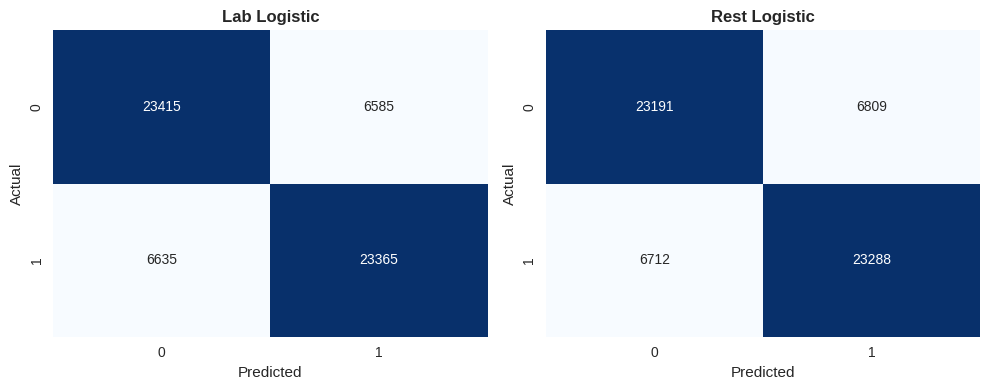

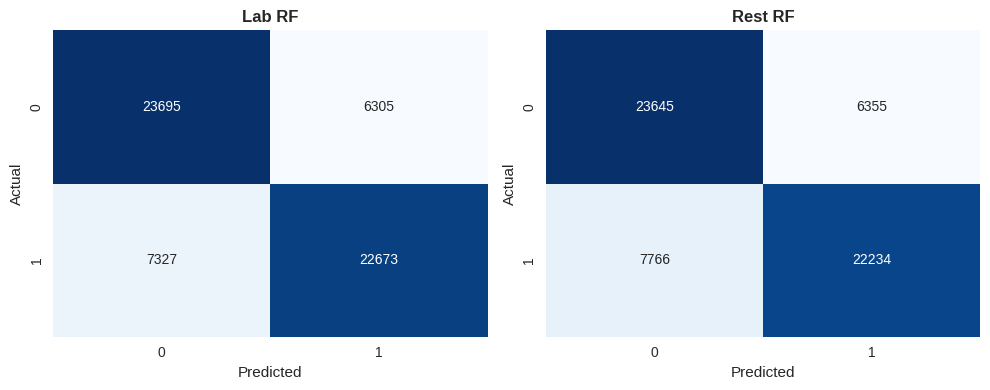

In [83]:
plot_confusion_matrices(
    metrics_lab_log, metrics_rest_log,
    metrics_lab_rf, metrics_rest_rf
)

The confusion matrices show balanced classification performance for both models across lab and rest frames. For Logistic Regression (lab), the model correctly classifies 23415 gluon jets and 23365 quark jets, with misclassifications of 6585 and 6635 respectively. In the rest frame, correct predictions slightly decrease to 23191 (gluon) and 23288 (quark), with a small increase in misclassifications.

For Random Forest, the lab frame achieves 23695 correct gluon and 22673 correct quark classifications, while the rest frame shows a slight decline with 23645 and 22234 respectively. The increase in misclassified quark jets (7327 → 7766) indicates reduced performance in the rest frame.

Overall, the results confirm that both models perform comparably, with the lab frame consistently yielding slightly better classification accuracy. The differences remain small, indicating that both feature representations are effective, but the rest frame does not provide a clear advantage.

## 🔹 Step D6: Feature Importance Analysis

### Objective:
Understand which features contribute most to classification.

### Methods:
- Random Forest → Feature importance  
- Logistic Regression → Absolute coefficients  

### Importance:
- Provides model interpretability  
- Links machine learning results to physics understanding  

In [84]:
# STEP D6: FEATURE IMPORTANCE

def plot_feature_importance(model, title):
    """
    Plots feature importance from Random Forest model.
    """

    feature_names = ["Mass", "Width", "pTD", "Multiplicity"]
    importances = model.feature_importances_

    plt.figure(figsize=(6,4))

    plt.bar(feature_names, importances)

    plt.title(title, fontsize=13, weight='bold')
    plt.ylabel("Importance")
    plt.xlabel("Features")

    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.show()

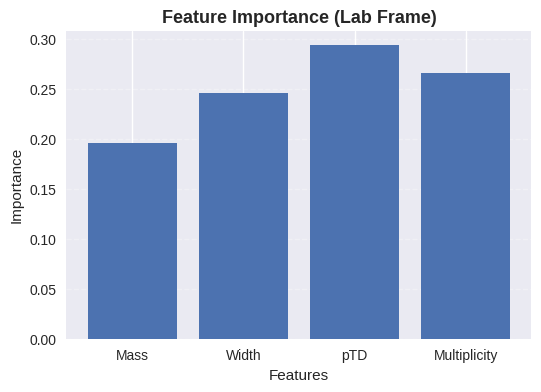

In [85]:
# Lab Frame
plot_feature_importance(model_lab_rf, "Feature Importance (Lab Frame)")


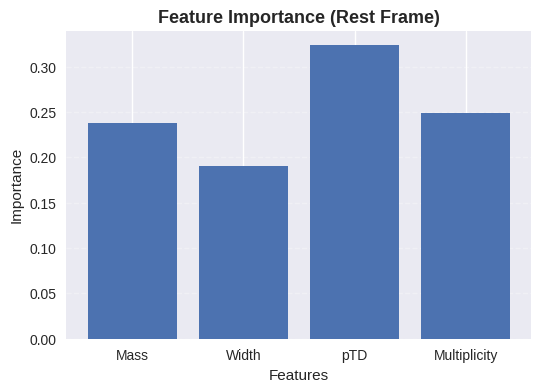

In [86]:
# Rest Frame
plot_feature_importance(model_rest_rf, "Feature Importance (Rest Frame)")

The feature importance analysis shows that pT dispersion (pTD) is the most dominant feature in both frames, with importance values of approximately 0.295 (lab) and 0.327 (rest). Multiplicity also contributes significantly, with values around 0.267 (lab) and 0.249 (rest). Jet width shows a noticeable decrease in importance when moving from lab (≈0.245) to rest frame (≈0.190), indicating reduced discriminative power after the boost. Mass has a moderate contribution, increasing slightly from ≈0.195 (lab) to ≈0.235 (rest). Overall, pTD and multiplicity remain the key features, while width becomes less informative in the rest frame.

## 🔹 Step D7: Final Comparison Summary

### Objective:
Provide a concise comparison of all models and feature sets.

### Includes:
- AUC comparison  
- Best model identification  
- Frame-wise performance comparison  
- Feature importance summary  

In [87]:
# STEP D7: FINAL SUMMARY (ALL MODELS)

def final_summary(metrics_lab_log, metrics_rest_log,
                  metrics_lab_rf, metrics_rest_rf,
                  model_lab_rf, model_rest_rf,
                  model_lab_log, model_rest_log):

    print("\n" + "="*50)
    print("FINAL COMPARISON SUMMARY")
    print("="*50 + "\n")

    # AUC Values
    print("AUC Scores:")
    print(f"  Lab Logistic : {metrics_lab_log['auc']:.4f}")
    print(f"  Rest Logistic: {metrics_rest_log['auc']:.4f}")
    print(f"  Lab RF       : {metrics_lab_rf['auc']:.4f}")
    print(f"  Rest RF      : {metrics_rest_rf['auc']:.4f}")

    print("\n" + "-"*50)

    # Best Model
    auc_values = {
        "Lab Logistic": metrics_lab_log['auc'],
        "Rest Logistic": metrics_rest_log['auc'],
        "Lab RF": metrics_lab_rf['auc'],
        "Rest RF": metrics_rest_rf['auc']
    }

    best_model = max(auc_values, key=auc_values.get)

    print(f"\nBest Performing Model: {best_model}")
    print(f"AUC: {auc_values[best_model]:.4f}")

    print("\n" + "-"*50)

    # Frame Comparison
    print("\nFrame Comparison:")
    print(f"  Logistic: {'Lab' if metrics_lab_log['auc'] > metrics_rest_log['auc'] else 'Rest'} performs better")
    print(f"  Random Forest: {'Lab' if metrics_lab_rf['auc'] > metrics_rest_rf['auc'] else 'Rest'} performs better")

    print("\n" + "-"*50)

    feature_names = ["Mass", "Width", "pTD", "Multiplicity"]

    # Logistic Importance (ABS COEFFICIENTS)
    print("\nFeature Importance (Logistic - Lab):")
    coef_lab = np.abs(model_lab_log.coef_[0])
    for name, val in zip(feature_names, coef_lab):
        print(f"  {name:<12}: {val:.4f}")

    print("\nFeature Importance (Logistic - Rest):")
    coef_rest = np.abs(model_rest_log.coef_[0])
    for name, val in zip(feature_names, coef_rest):
        print(f"  {name:<12}: {val:.4f}")

    print("\n" + "-"*50)

    # RF Importance
    print("\nFeature Importance (RF - Lab):")
    for name, val in zip(feature_names, model_lab_rf.feature_importances_):
        print(f"  {name:<12}: {val:.4f}")

    print("\nFeature Importance (RF - Rest):")
    for name, val in zip(feature_names, model_rest_rf.feature_importances_):
        print(f"  {name:<12}: {val:.4f}")

    print("\n" + "="*50)

In [88]:
final_summary(
    metrics_lab_log, metrics_rest_log,
    metrics_lab_rf, metrics_rest_rf,
    model_lab_rf, model_rest_rf,
    model_lab_log, model_rest_log
)


FINAL COMPARISON SUMMARY

AUC Scores:
  Lab Logistic : 0.8522
  Rest Logistic: 0.8483
  Lab RF       : 0.8487
  Rest RF      : 0.8400

--------------------------------------------------

Best Performing Model: Lab Logistic
AUC: 0.8522

--------------------------------------------------

Frame Comparison:
  Logistic: Lab performs better
  Random Forest: Lab performs better

--------------------------------------------------

Feature Importance (Logistic - Lab):
  Mass        : 0.8413
  Width       : 1.2235
  pTD         : 0.6918
  Multiplicity: 1.4620

Feature Importance (Logistic - Rest):
  Mass        : 0.2131
  Width       : 0.1144
  pTD         : 0.6059
  Multiplicity: 1.3723

--------------------------------------------------

Feature Importance (RF - Lab):
  Mass        : 0.1954
  Width       : 0.2454
  pTD         : 0.2934
  Multiplicity: 0.2659

Feature Importance (RF - Rest):
  Mass        : 0.2376
  Width       : 0.1899
  pTD         : 0.3233
  Multiplicity: 0.2492



### Observation:

- Logistic Regression slightly outperforms Random Forest  
- Lab frame consistently performs better than rest frame  
- Best performing setup: Lab Logistic Regression  

# Thank You ✌️🫡